In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

def isovelocity_curves(M_star=1.0, incl=45., PA=90., V_sys=0., distance=140., Ngrid=512, Rgrid=1024):
    
    # Constants (using SI / MKS units)
    M_sun = 1.989e30
    
    # Convert projection angles to radians
    incl_r = np.radians(incl)
    pa_r = np.radians(PA)
    
    # Sky-plane grid, defined in arcsecond offsets
    x_arcsec = np.linspace(-Rgrid / distance, Rgrid / distance, Ngrid)
    y_arcsec = np.linspace(-Rgrid / distance, Rgrid / distance, Ngrid)
    X_sky, Y_sky = np.meshgrid(x_arcsec, y_arcsec)
    
    # Rotate to account for PA (aligns the coordinates so X_disk is along the projected major axis)
    X_rot =  X_sky * np.sin(pa_r) + Y_sky * np.cos(pa_r)
    Y_rot = -X_sky * np.cos(pa_r) + Y_sky * np.sin(pa_r)
    
    # Deproject to the disk coordinate frame (physical distances -- in this case, in meters)
    X_disk = X_rot * distance * sc.au
    Y_disk = (Y_rot / np.cos(incl_r)) * distance * sc.au
    R_disk = np.sqrt(X_disk**2 + Y_disk**2)
    
    # Keplerian velocities (in m / s)
    with np.errstate(divide='ignore', invalid='ignore'):
        V_kep = np.sqrt((sc.G * M_star * M_sun) / R_disk)
        
    # project those velocities along the line of sight: V_los = V_sys + V_kep * sin(i) * cos(theta)
    # where theta is the azimuth angle in the disk frame, defined such that cos(theta) = X_disk / R_disk
    cos_theta = X_disk / R_disk
    V_los = V_sys + V_kep * np.sin(incl_r) * cos_theta
    
    # Mask out the very center or outside edge if necessary
    V_los[R_disk > (Rgrid * sc.au)] = np.nan
    
    return X_sky, Y_sky, V_los

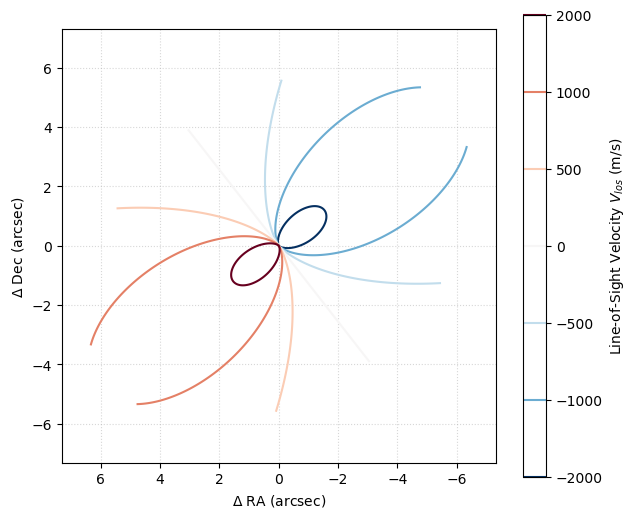

In [29]:
# make the isovelocity grid (projected, line-of-sight velocities for each X, Y pixel)
X, Y, V_los = isovelocity_curves(M_star=2.3, incl=47., PA=128.)

# --- Plotting ---
plt.figure(figsize=(7, 6))
# Define specific velocity channels
levels = np.arange(-5000.0, 5000.0, 2500)
levels = [-2000, -1000, -500, 0, 500, 1000, 2000]

contour = plt.contour(X, Y, V_los, levels=levels, cmap='RdBu_r', linewidths=1.5)

plt.xlabel("$\Delta$ RA (arcsec)")
plt.ylabel("$\Delta$ Dec (arcsec)")
plt.gca().invert_xaxis() # Invert RA to match standard astronomical orientation
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.5)
plt.colorbar(contour, label='Line-of-Sight Velocity $V_{los}$ (m/s)')

plt.show();